# Create TPM data
June 17, 2025

**Goals:**
Load the genic and nongenic dataset and RNA seq data. Create TPM data set from the combined transcripts datasets for each replicate and sample.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
from src.transcripts_dataset import load_transcripts_sets

output_dir = 'output/draft4_run/'

combined_gene_nongenic = load_transcripts_sets(output_dir, combined=True)
combined_gene_nongenic.head()

In [34]:
from src.tpm_calculator import TPMGenerator
output_dir = 'output/draft4_run/'

tpm_generator = TPMGenerator(combined_gene_nongenic, output_dir)


In [41]:
from src.read_bam import get_rna_seq_filepaths_df
bam_df = get_rna_seq_filepaths_df()

tpm_generator.process_multiple_replicates(
    bam_df, chroms=[1])



=== Processing Replicate 1 ===
Reading BAM file for time 0 minutes
1..Done. 00:00:05.584
Reading BAM file for time 10 minutes
1..Done. 00:00:11.555
Reading BAM file for time 20 minutes
1..Done. 00:00:17.800
Reading BAM file for time 30 minutes
1..Done. 00:00:23.362
Reading BAM file for time 40 minutes
1..Done. 00:00:28.928
Reading BAM file for time 50 minutes
1..Done. 00:00:34.587
Reading BAM file for time 60 minutes
1..Done. 00:00:40.073
Reading BAM file for time 70 minutes
1..Done. 00:00:45.568
Reading BAM file for time 80 minutes
1..Done. 00:00:51.053
Reading BAM file for time 90 minutes
1..Done. 00:00:56.490
Reading BAM file for time 100 minutes
1..Done. 00:01:02.126
Reading BAM file for time 110 minutes
1..Done. 00:01:08.439
Reading BAM file for time 120 minutes
1..Done. 00:01:13.735
Reading BAM file for time 130 minutes
1..Done. 00:01:19.511
Reading BAM file for time 140 minutes
1..Done. 00:01:25.347
Reading BAM file for time 150 minutes
1..Done. 00:01:31.160
Saved results for r

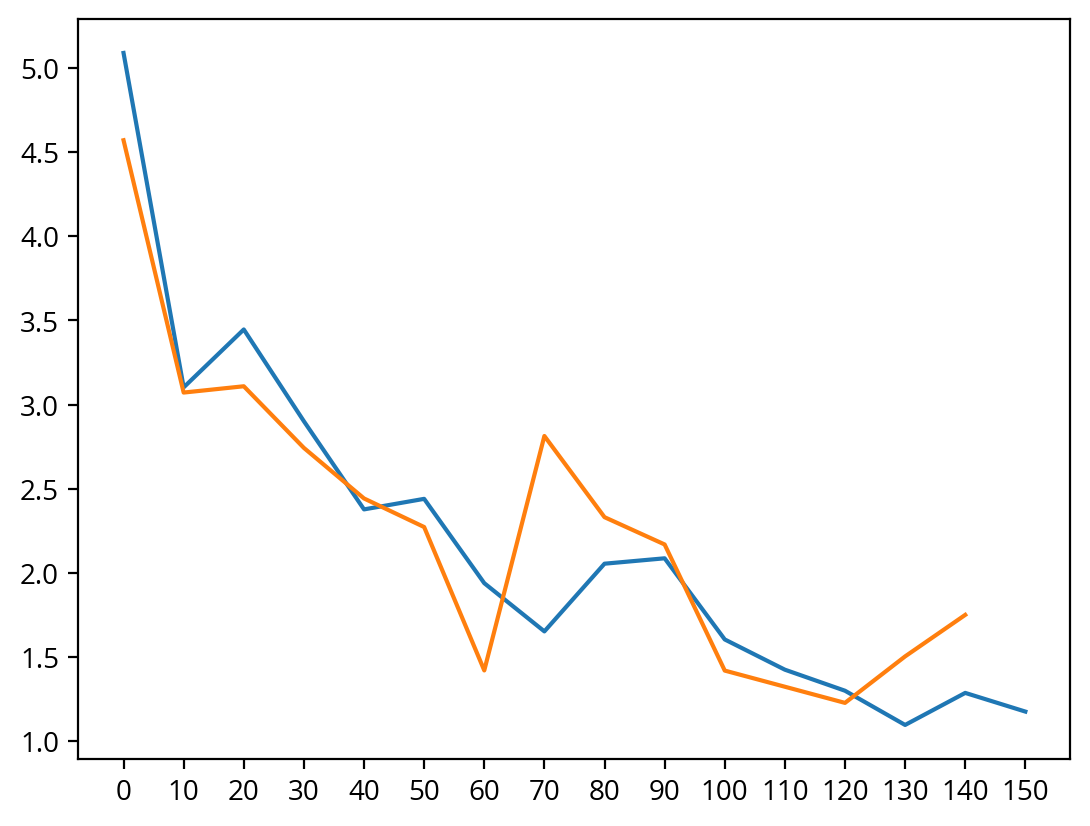

In [93]:
from src.gene_expression import load_transcription_for_name


expression_rep1 = load_transcription_for_name('nogene_chr16_775917_776355', 1)
expression_rep2 = load_transcription_for_name('nogene_chr16_775917_776355', 2)

plt.plot(expression_rep1)
plt.plot(expression_rep2)

In [106]:
from src.transcripts_dataset import load_transcripts_sets

combined_transcripts_set = load_transcripts_sets(output_dir, combined=True)
combined_transcripts_set

,chr,strand,start,stop,length
YAL068C,1,-,1807,2169,362
YAL067W-A,1,+,2480,2707,227
YAL067C,1,-,7235,9016,1781
YAL065C,1,-,11565,11951,386
YAL064W-B,1,+,12046,12426,380
...,...,...,...,...,...
nogene_chr16_883764_884048,16,-,883764,884048,285
nogene_chr16_900044_900421,16,-,900044,900421,378
nogene_chr16_930038_930990,16,-,930038,930990,953
nogene_chr16_937119_939102,16,+,937119,939102,1984


In [94]:
from pipeline.CombinedDeconvolveGeneExpressionRunner import CombinedDeconvolveGeneExpressionRunner

tx_deconv_runner = CombinedDeconvolveGeneExpressionRunner(output_dir)

In [99]:
tx_deconv_runner.deconvolve_transcript_optimal_gamma('nogene_chr16_775917_776355',
    kappa=0.001, eta=0.264)


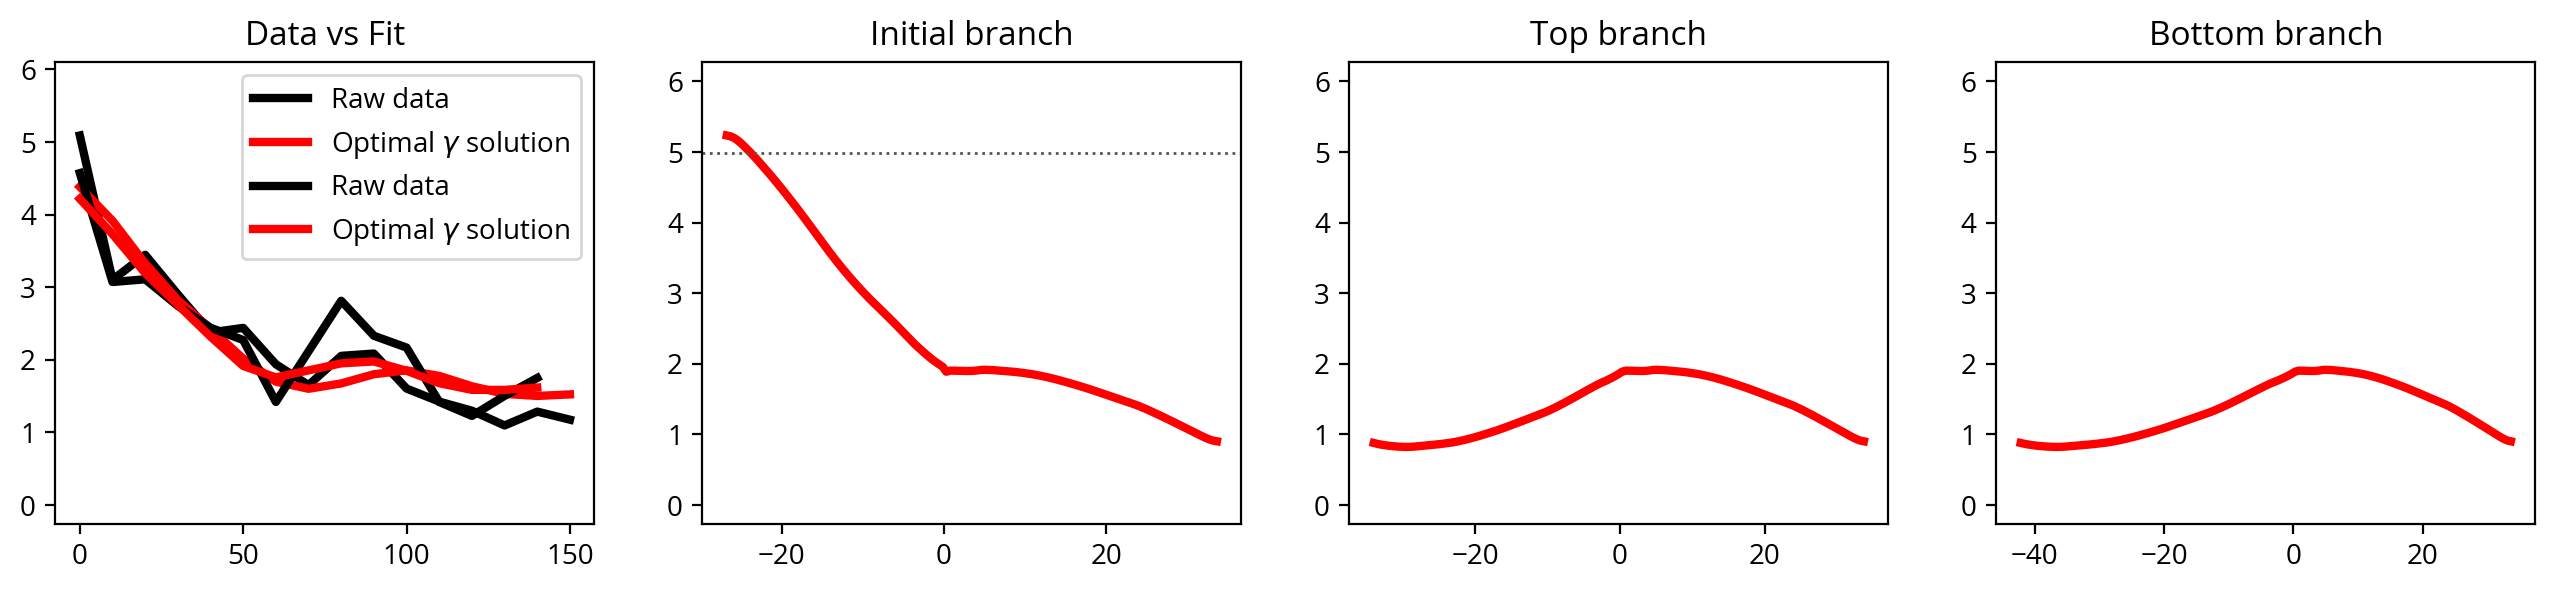

In [100]:
tx_deconv_runner.plot_solution()

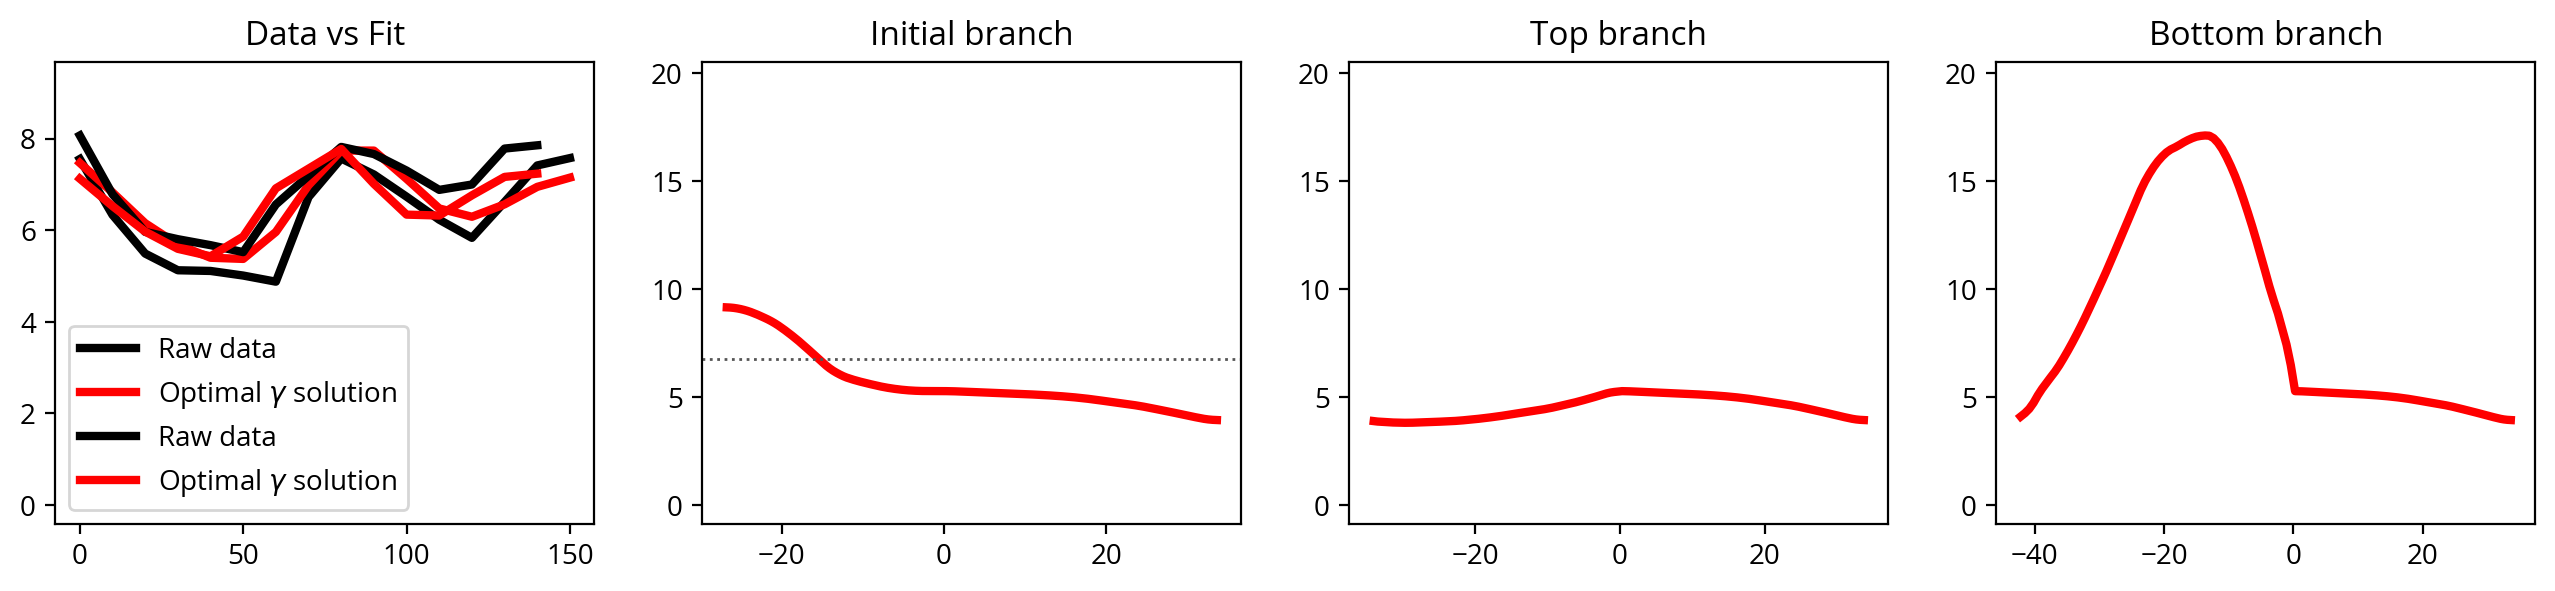

In [104]:
tx_deconv_runner.deconvolve_gene_optimal_gamma('DSE1',
    kappa=0.001, eta=0.264)
tx_deconv_runner.plot_solution()

In [116]:
from src.orf_plotter import load_default_orf_plotter

orf_plotter = load_default_orf_plotter()
orf_plotter.set_span_chrom((760000, 780000), 16)

<Axes: >

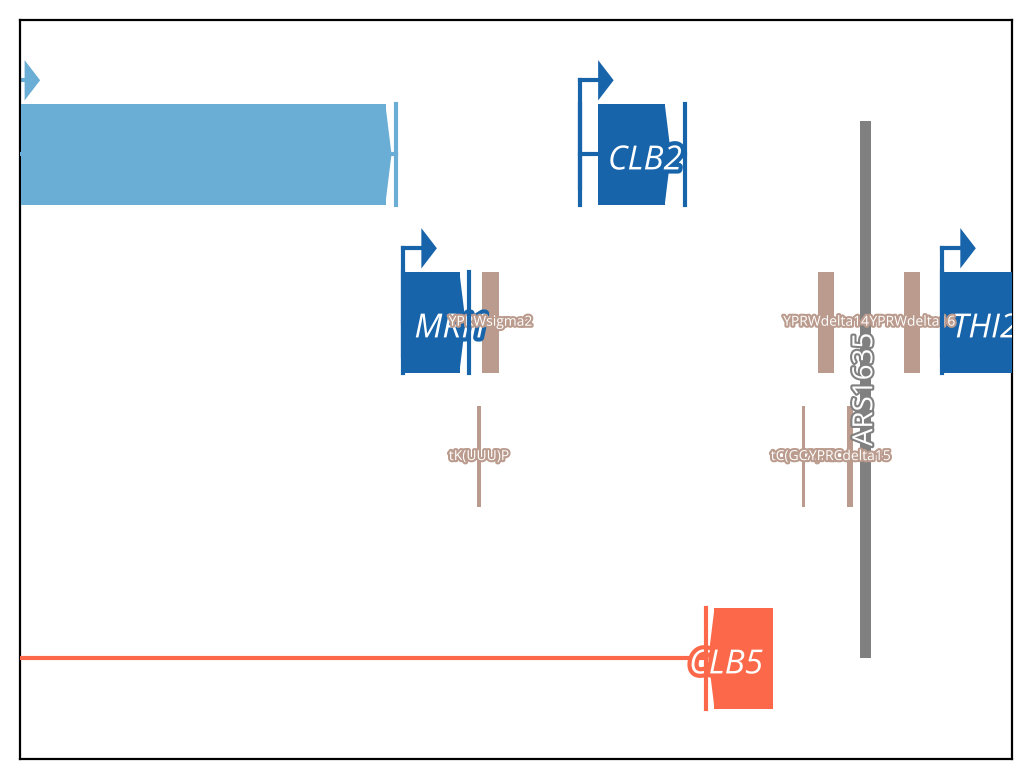

In [117]:
orf_plotter.plot_orf_annotations(plt.gca())